Load cleaned_data.csv from Part 1

In [63]:
import pandas as pd
df = pd.read_csv("../Part-1/cleaned_data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00


In [64]:
# Feature matrix
X = df.drop("price", axis=1)

# Regression target
y_reg = df["price"]

# Classification target
median_price = y_reg.median()
y_clf = (y_reg >= median_price).astype(int)

In [65]:
print("X shape:", X.shape)
print("Regression Target shape:", y_reg.shape)
print("Classification Target shape:", y_clf.shape)
print("\nMedian Price:", median_price)
print("\nClassification Counts:")
print(y_clf.value_counts())

X shape: (12790, 8)
Regression Target shape: (12790,)
Classification Target shape: (12790,)

Median Price: 73.0

Classification Counts:
price
1    6415
0    6375
Name: count, dtype: int64


In [66]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

Encode categorical columns

In [67]:
# Identify categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(cat_cols)

# One-Hot Encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after encoding:", X.shape)
X.head()

Categorical Columns:
Index(['area_type', 'availability', 'location', 'size', 'society'], dtype='object')
Shape after encoding: (12790, 4107)


,total_sqft,bath,balcony,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_14-Nov,availability_15-Aug,availability_15-Dec,availability_15-Jun,...,society_Xeitaa,society_YCnce R,society_YMhenLi,society_Yaenti,society_ZeodsWo,society_Zonce E,society_Zostaa,society_i1ncyRe,society_i1odsne,society_i1rtsCo
0,1056.0,2.0,1.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Leak-free train-test split and scaling

In [68]:
# Fill missing values with column means
X = X.fillna(X.mean(numeric_only=True))

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression split
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

# Classification split
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf,
    test_size=0.2,
    random_state=42
)

# Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Shape :", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape)

Training Shape : (10232, 4107)
Testing Shape : (2558, 4107)


In [70]:
import numpy as np

print(np.isnan(X_train_scaled).sum())
print(np.isnan(X_test_scaled).sum())

0
0


In [71]:
import numpy as np
import pandas as pd

print("NaN in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN in X_test_scaled:", np.isnan(X_test_scaled).sum())
print("NaN in y_reg_train:", pd.isna(y_reg_train).sum())
print("NaN in y_reg_test:", pd.isna(y_reg_test).sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0
NaN in y_reg_train: 0
NaN in y_reg_test: 0


Regression model — Linear Regression

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Train model
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)

# Predictions
y_pred_reg = lr.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Mean Squared Error :", mse)
print("R² Score :", r2)

Mean Squared Error : 17603.348802794237
R² Score : 0.284930955863656


In [73]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
1073,location_Ramakrishnappa Layout,42.743020
447,location_Defence Colony,40.536968
0,total_sqft,37.954331
2916,society_PeBayle,-33.402648
2071,society_Epllan,30.090907
482,location_Dodsworth Layout,27.935612
1107,location_Sadashiva Nagar,24.061454
871,location_Malleshwaram,21.365486
1,bath,20.042680
1408,size_4 Bedroom,19.744704


In [74]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)

ridge_pred = ridge.predict(X_test_scaled)

In [75]:
ridge_mse = mean_squared_error(y_reg_test, ridge_pred)
ridge_r2 = r2_score(y_reg_test, ridge_pred)

print("Ridge Regression")
print("Mean Squared Error:", ridge_mse)
print("R² Score:", ridge_r2)

Ridge Regression
Mean Squared Error: 17591.035865067173
R² Score: 0.2854311220939362


In [76]:
print("Linear Regression R² :", r2)
print("Ridge Regression R² :", ridge_r2)

print("Linear Regression MSE :", mse)
print("Ridge Regression MSE :", ridge_mse)

Linear Regression R² : 0.284930955863656
Ridge Regression R² : 0.2854311220939362
Linear Regression MSE : 17603.348802794237
Ridge Regression MSE : 17591.035865067173


In [77]:
import pandas as pd

ridge_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
})

ridge_coef = ridge_coef.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

ridge_coef.head(10)

,Feature,Coefficient
1073,location_Ramakrishnappa Layout,42.534786
447,location_Defence Colony,40.327204
0,total_sqft,37.962250
2916,society_PeBayle,-33.374773
2071,society_Epllan,30.081193
482,location_Dodsworth Layout,27.639919
1107,location_Sadashiva Nagar,23.789092
871,location_Malleshwaram,20.744366
1,bath,20.047402
1408,size_4 Bedroom,19.725384


5(a) Classification model — Logistic Regression

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [79]:
print(y_clf_train.value_counts(normalize=True))

price
1    0.500391
0    0.499609
Name: proportion, dtype: float64


In [80]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_clf_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]


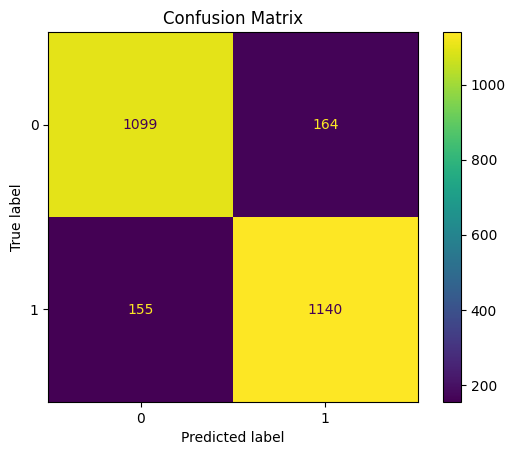

In [81]:

import matplotlib.pyplot as plt
cm = confusion_matrix(y_clf_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [82]:
print("Accuracy :", accuracy_score(y_clf_test, y_pred))
print("Precision:", precision_score(y_clf_test, y_pred))
print("Recall   :", recall_score(y_clf_test, y_pred))
print("F1 Score :", f1_score(y_clf_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_clf_test, y_pred))

Accuracy : 0.8752931978107896
Precision: 0.8742331288343558
Recall   : 0.8803088803088803
F1 Score : 0.8772604848018468

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1263
           1       0.87      0.88      0.88      1295

    accuracy                           0.88      2558
   macro avg       0.88      0.88      0.88      2558
weighted avg       0.88      0.88      0.88      2558



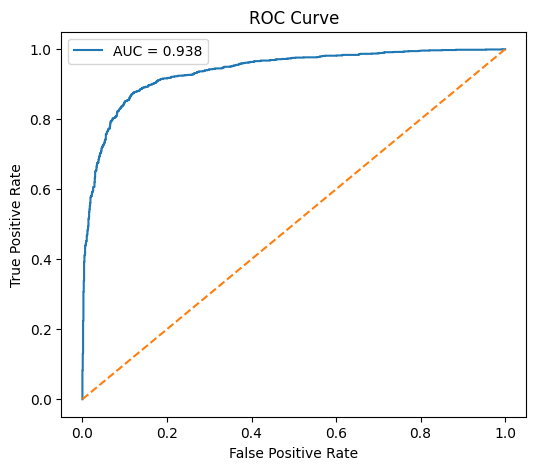

AUC Score: 0.9375614841173036


In [83]:
fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob)

auc = roc_auc_score(y_clf_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", auc)

5(b)-Decision-threshold sensitivity

In [84]:
import pandas as pd

thresholds = [0.30,0.40,0.50,0.60,0.70]

results = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    precision = precision_score(y_clf_test, pred)
    recall = recall_score(y_clf_test, pred)
    f1 = f1_score(y_clf_test, pred)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1 Score"]
)

print(threshold_df)

   Threshold  Precision    Recall  F1 Score
0        0.3   0.841840  0.904247  0.871929
1        0.4   0.859911  0.891120  0.875237
2        0.5   0.874233  0.880309  0.877260
3        0.6   0.887828  0.861776  0.874608
4        0.7   0.898515  0.840927  0.868767


Regularization experiment on Logistic Regression

In [85]:
model_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

model_c001.fit(X_train_scaled, y_clf_train)
y_pred_c001 = model_c001.predict(X_test_scaled)
y_prob_c001 = model_c001.predict_proba(X_test_scaled)[:, 1]

In [86]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

baseline_precision = precision_score(y_clf_test, y_pred)
baseline_recall = recall_score(y_clf_test, y_pred)
baseline_auc = roc_auc_score(y_clf_test, y_prob)

c001_precision = precision_score(y_clf_test, y_pred_c001)
c001_recall = recall_score(y_clf_test, y_pred_c001)
c001_auc = roc_auc_score(y_clf_test, y_prob_c001)

In [87]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline (C=1.0)", "Regularized (C=0.01)"],
    "Precision": [baseline_precision, c001_precision],
    "Recall": [baseline_recall, c001_recall],
    "AUC": [baseline_auc, c001_auc]
})

print(comparison)

                  Model  Precision    Recall       AUC
0      Baseline (C=1.0)   0.874233  0.880309  0.937561
1  Regularized (C=0.01)   0.869331  0.873359  0.940276


Bootstrap confidence interval for AUC difference

In [88]:
import numpy as np
from sklearn.metrics import roc_auc_score

In [89]:
np.random.seed(42)

n_bootstraps = 500
auc_differences = []

for i in range(n_bootstraps):

    indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    y_true = y_clf_test.iloc[indices]

    prob_baseline = y_prob[indices]
    prob_regularized = y_prob_c001[indices]

    auc1 = roc_auc_score(y_true, prob_baseline)
    auc2 = roc_auc_score(y_true, prob_regularized)

    auc_differences.append(auc1 - auc2)

In [90]:
mean_diff = np.mean(auc_differences)

lower = np.percentile(auc_differences, 2.5)
upper = np.percentile(auc_differences, 97.5)

print("Mean AUC Difference :", mean_diff)
print("95% Confidence Interval :", (lower, upper))

Mean AUC Difference : -0.0026700385046143564
95% Confidence Interval : (np.float64(-0.005778793574447089), np.float64(0.0002944016039636027))


In [91]:
if lower > 0 or upper < 0:
    print("The confidence interval excludes zero.")
    print("The performance difference is statistically reliable.")
else:
    print("The confidence interval includes zero.")
    print("The performance difference may not be reliable.")

The confidence interval includes zero.
The performance difference may not be reliable.
